# Customer Churn Prediction

## Project Overview

This project analyzes customer churn using exploratory data analysis, data cleaning, categorical encoding, multicollinearity analysis, and classification models.

The objective is to identify patterns associated with customer churn and evaluate machine learning models for predicting whether a customer is likely to churn.

## Objectives

- Understand the structure and quality of the customer dataset
- Explore churn patterns across customer characteristics and services
- Clean and prepare customer data for modeling
- Encode categorical variables
- Investigate multicollinearity using Variance Inflation Factor (VIF)
- Build Logistic Regression and Random Forest classification models
- Evaluate model performance using classification metrics

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

## 2. Load and Understand the Dataset

In [2]:
df=pd.read_csv('customer_churn.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Quality & Cleaning

In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df.duplicated().sum()

np.int64(0)

## 4. Exploratory Data Analysis

In [7]:
df.dtypes[df.dtypes=='object']
df.select_dtypes(include='object').columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [8]:
df.select_dtypes(include='number').columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [9]:
churnrate=round(pd.crosstab(df['gender'],df['Churn'],normalize='index')*100,1)

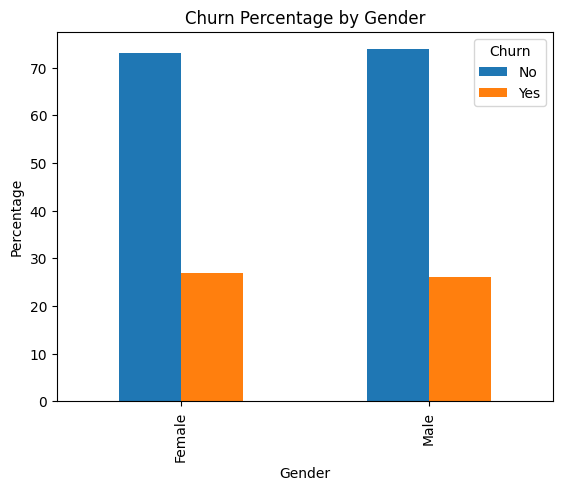

In [10]:
churnrate.plot(kind='bar')
plt.title("Churn Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

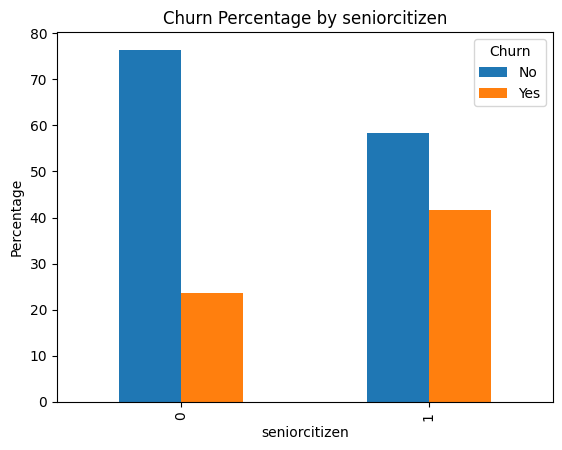

In [11]:
churnrate=round(pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize='index')*100,1)
churnrate.plot(kind='bar')
plt.title("Churn Percentage by seniorcitizen")
plt.xlabel("seniorcitizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

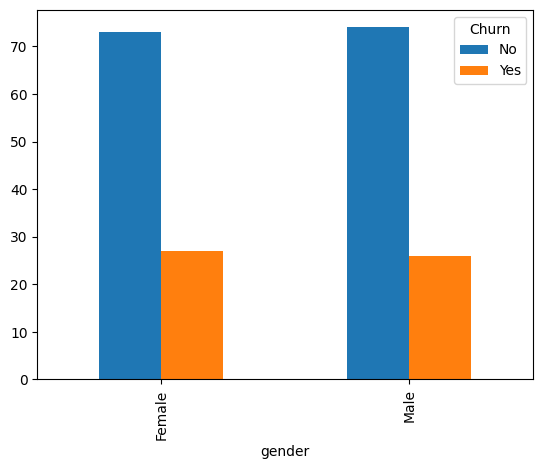

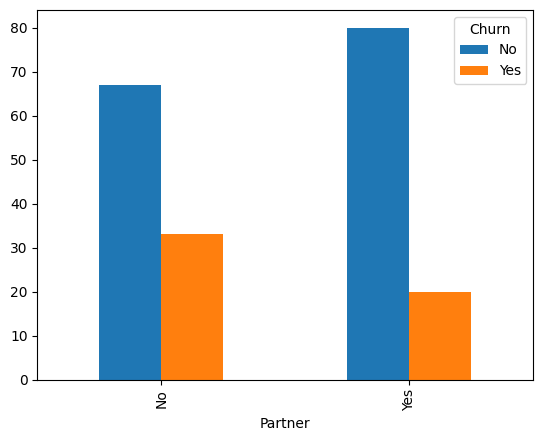

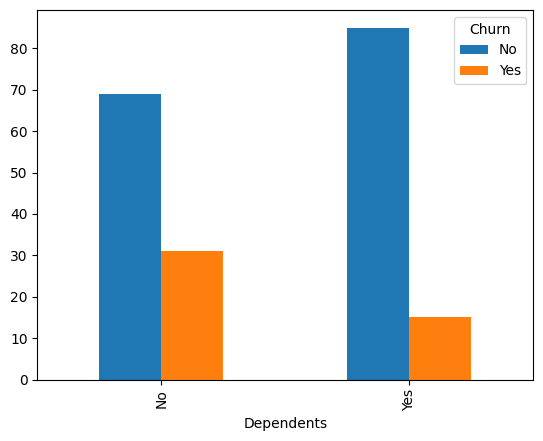

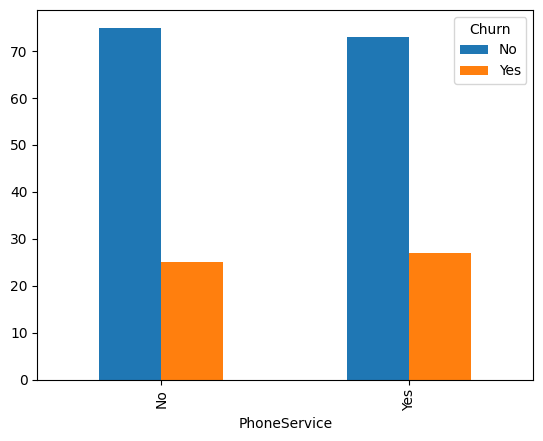

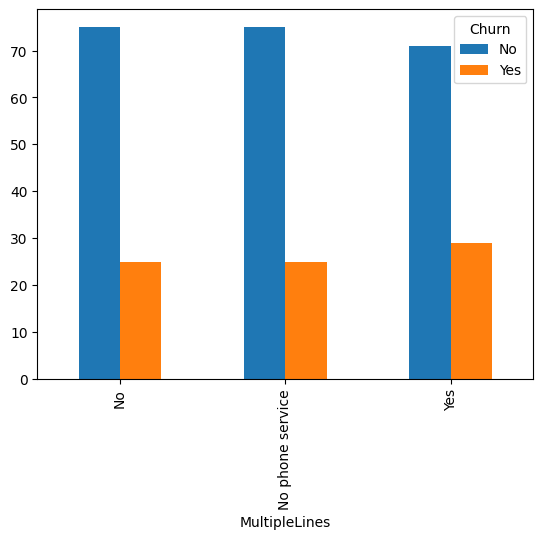

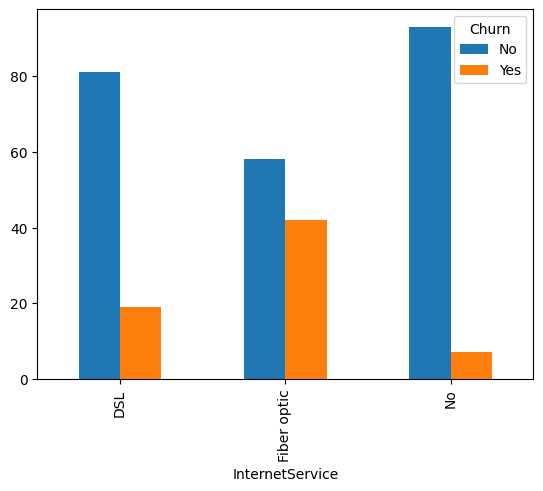

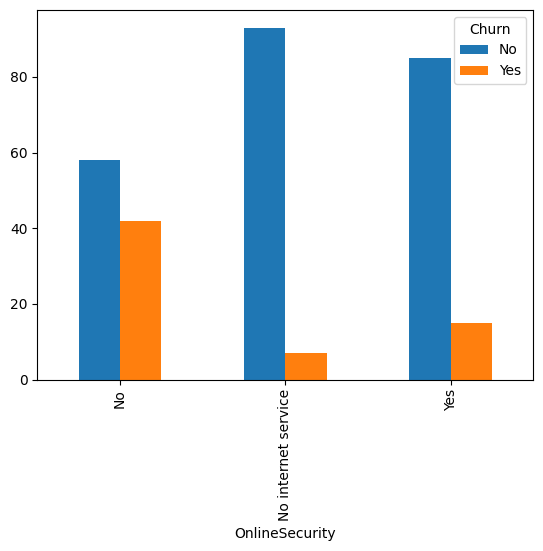

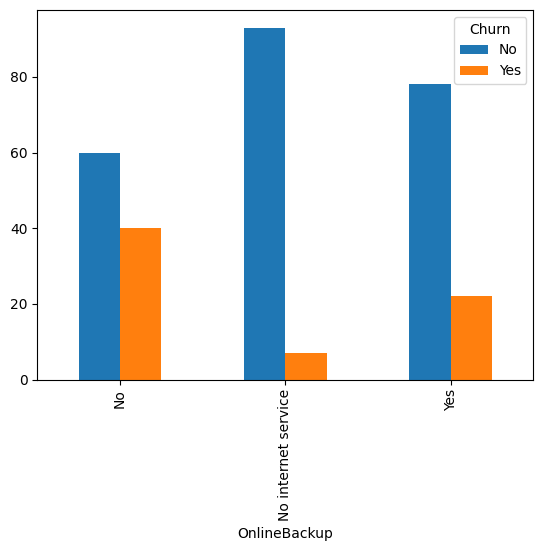

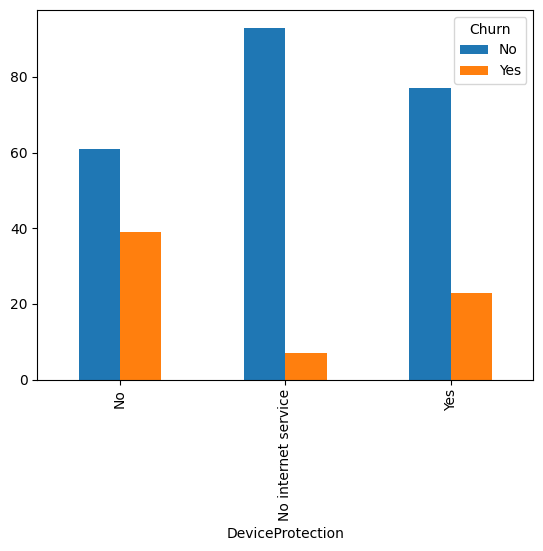

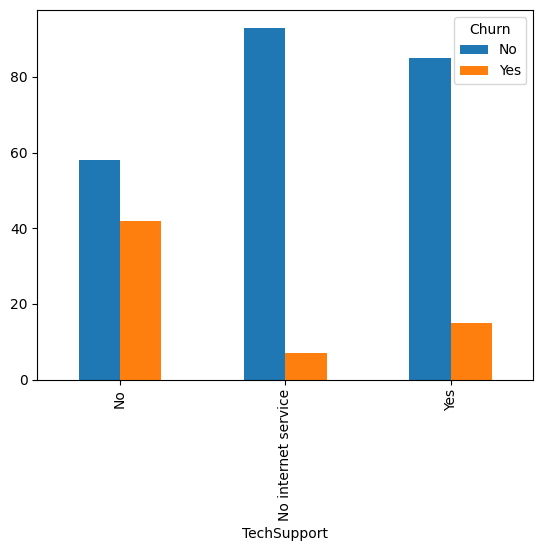

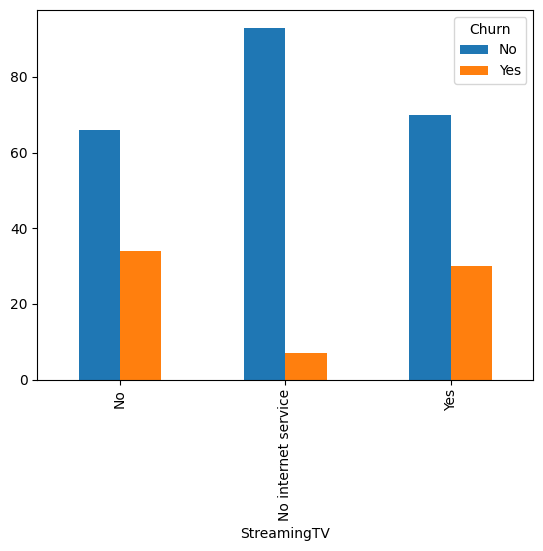

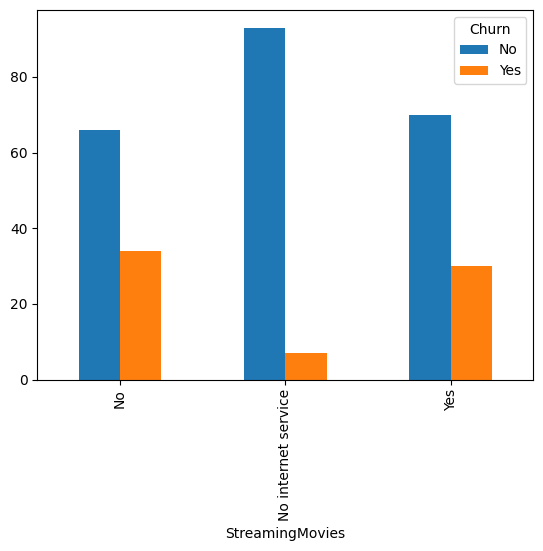

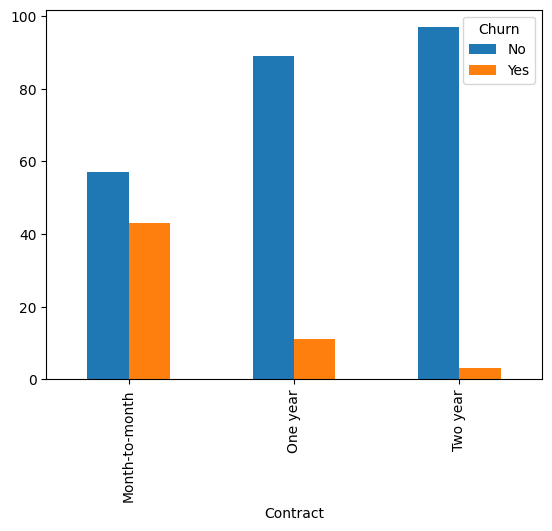

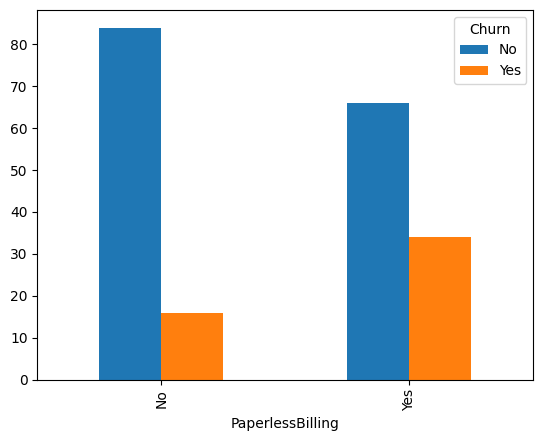

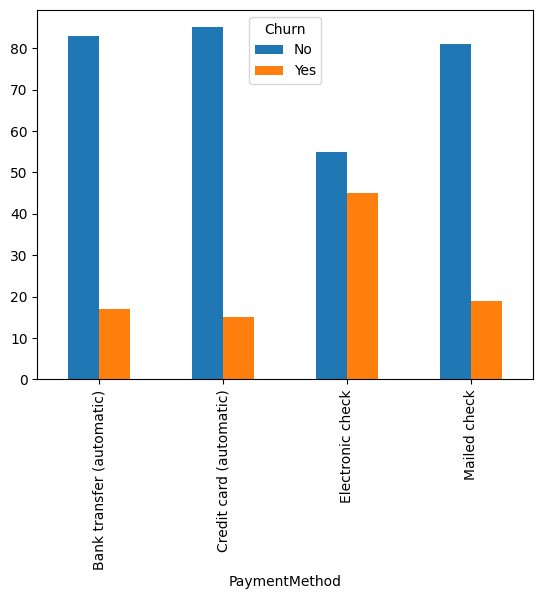

In [12]:
cols=['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod']
for i in cols:
    churnrate=round(pd.crosstab(df[i],df['Churn'],normalize='index')*100).plot(kind='bar')

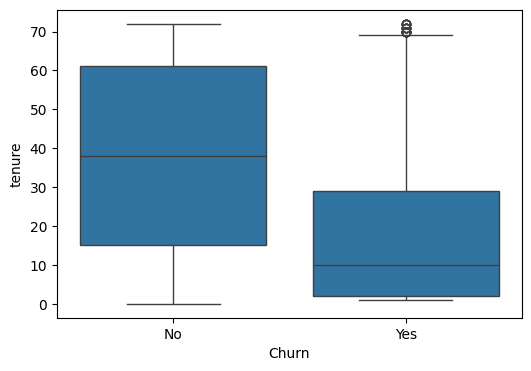

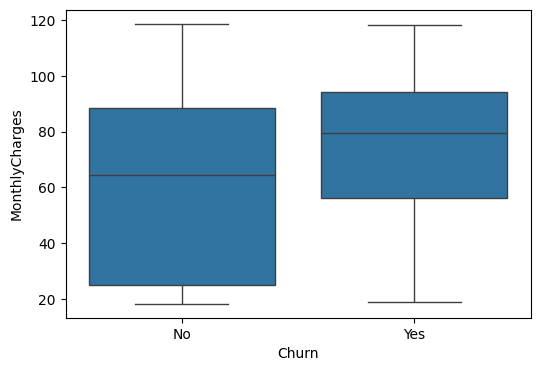

In [13]:
cols=['tenure','MonthlyCharges']
for i in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn',y=i,data=df)
    plt.show()

In [14]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [15]:
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)

In [16]:
df.dropna(inplace=True)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

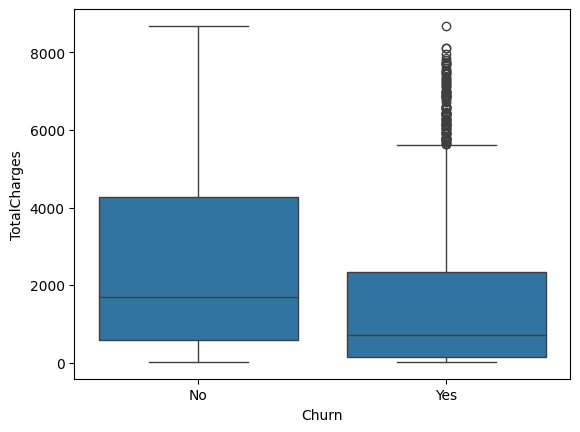

In [17]:
df['TotalCharges']=df['TotalCharges'].astype('float64')
sns.boxplot(x='Churn',y='TotalCharges',data=df)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [19]:
df1=df.drop(columns='customerID')
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

## 5. Feature Preparation

In [20]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


In [21]:
for i in df1.columns:
    if df1[i].dtype=='object':
        df1[i]=le.fit_transform(df1[i])
        print("order of encoding for",i,"is",le.classes_)

order of encoding for gender is ['Female' 'Male']
order of encoding for Partner is ['No' 'Yes']
order of encoding for Dependents is ['No' 'Yes']
order of encoding for PhoneService is ['No' 'Yes']
order of encoding for MultipleLines is ['No' 'No phone service' 'Yes']
order of encoding for InternetService is ['DSL' 'Fiber optic' 'No']
order of encoding for OnlineSecurity is ['No' 'No internet service' 'Yes']
order of encoding for OnlineBackup is ['No' 'No internet service' 'Yes']
order of encoding for DeviceProtection is ['No' 'No internet service' 'Yes']
order of encoding for TechSupport is ['No' 'No internet service' 'Yes']
order of encoding for StreamingTV is ['No' 'No internet service' 'Yes']
order of encoding for StreamingMovies is ['No' 'No internet service' 'Yes']
order of encoding for Contract is ['Month-to-month' 'One year' 'Two year']
order of encoding for PaperlessBilling is ['No' 'Yes']
order of encoding for PaymentMethod is ['Bank transfer (automatic)' 'Credit card (automati

In [22]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

In [23]:
df1['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x=df1.drop(columns='Churn')
y=df1['Churn']


## 6. Train-Test Split

In [26]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,stratify=y,random_state=100,test_size=0.2)

## 7. Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [28]:
model.fit(xtrain,ytrain)

LogisticRegression()

In [29]:
ypred = model.predict(xtest)
yprob = model.predict_proba(xtest)[:, 1]

In [30]:
from sklearn.metrics import roc_auc_score,accuracy_score

In [31]:
print("Accuracy:", accuracy_score(ytest, ypred))
print("ROC-AUC:", roc_auc_score(ytest, yprob))

Accuracy: 0.7967306325515281
ROC-AUC: 0.8364997851644397


## 8. Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
modelr=RandomForestClassifier()

In [34]:
modelr.fit(xtrain,ytrain)

RandomForestClassifier()

In [35]:
rpred=modelr.predict(xtest)

In [36]:
accuracy_score(ytest,rpred)

0.7810945273631841

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(ytest, rpred))
print(classification_report(ytest, rpred))

[[931 102]
 [206 168]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



## 9. Multicollinearity Analysis

In [38]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# list=df1.drop(columns='Churn').columns.tolist()
# vif=pd.DataFrame()
# vif['names']=df1[list].columns
# vif['vifscore']=[]
# for i in range(len(df1[list].columns)):
#     vif['vifscore'].append(variance_inflation_factor(df1[list].values,i))
# vif
# #this does not work as a list cannot cannot be attached to single row of dataframe





In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
 # Contain all numerical column after excluding charges column
list=[]
for i in df1.columns:
   if df1[i].name!=df['Churn'].name:
       list.append(i)

#instead of above code we can use this
#list=df1.drop(columns='Churn').columns.tolist()#but permanently removes churn column so use 1st method

vif_data = pd.DataFrame()   # Create a empty data frame to store column name and its VIF score

# Create a column in datafraem to store all column names from list
vif_data["Feature_names"] = df1[list].columns
# Create a column in dataframe to store VIF score of all column
vif_data["VIF score"] = [variance_inflation_factor(df1[list].values,i) for i in range(len(df1[list].columns))]

print(vif_data)

       Feature_names  VIF score
0             gender   1.001876
1      SeniorCitizen   1.149648
2            Partner   1.461171
3         Dependents   1.379721
4             tenure   7.493654
5       PhoneService   1.622695
6      MultipleLines   1.395898
7    InternetService   1.824359
8     OnlineSecurity   1.268758
9       OnlineBackup   1.219068
10  DeviceProtection   1.297942
11       TechSupport   1.321878
12       StreamingTV   1.446947
13   StreamingMovies   1.447896
14          Contract   2.493335
15  PaperlessBilling   1.202566
16     PaymentMethod   1.186112
17    MonthlyCharges   4.967861
18      TotalCharges  10.618697


In [41]:
df1[list].values

array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 2.0000e+00, 2.9850e+01,
        2.9850e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 3.0000e+00, 5.6950e+01,
        1.8895e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 3.0000e+00, 5.3850e+01,
        1.0815e+02],
       ...,
       [0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 2.0000e+00, 2.9600e+01,
        3.4645e+02],
       [1.0000e+00, 1.0000e+00, 1.0000e+00, ..., 3.0000e+00, 7.4400e+01,
        3.0660e+02],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0565e+02,
        6.8445e+03]])

In [42]:
df1.drop(columns='MonthlyCharges',inplace=True)

In [43]:
list=[]
for i in df1.columns:
   if df1[i].name!=df['Churn'].name:
       list.append(i)

vif_data = pd.DataFrame()   # Create a empty data frame to store column name and its VIF score

# Create a column in datafraem to store all column names from list
vif_data["Feature_names"] = df1[list].columns
# Create a column in dataframe to store VIF score of all column
vif_data["VIF score"] = [variance_inflation_factor(df1[list].values,i) for i in range(len(df1[list].columns))]

print(vif_data)

       Feature_names  VIF score
0             gender   1.001641
1      SeniorCitizen   1.138854
2            Partner   1.460779
3         Dependents   1.377526
4             tenure   5.845404
5       PhoneService   1.376999
6      MultipleLines   1.327503
7    InternetService   1.552912
8     OnlineSecurity   1.252521
9       OnlineBackup   1.215311
10  DeviceProtection   1.297926
11       TechSupport   1.308989
12       StreamingTV   1.402763
13   StreamingMovies   1.408386
14          Contract   2.450141
15  PaperlessBilling   1.167779
16     PaymentMethod   1.174591
17      TotalCharges   5.835927


In [44]:
df1.drop(columns='tenure',inplace=True)

In [45]:
list=[]
for i in df1.columns:
   if df1[i].name!=df['Churn'].name:
       list.append(i)

vif_data = pd.DataFrame()   # Create a empty data frame to store column name and its VIF score

# Create a column in datafraem to store all column names from list
vif_data["Feature_names"] = df1[list].columns
# Create a column in dataframe to store VIF score of all column
vif_data["VIF score"] = [variance_inflation_factor(df1[list].values,i) for i in range(len(df1[list].columns))]

print(vif_data)

       Feature_names  VIF score
0             gender   1.001501
1      SeniorCitizen   1.138831
2            Partner   1.439595
3         Dependents   1.377491
4       PhoneService   1.293361
5      MultipleLines   1.327258
6    InternetService   1.460718
7     OnlineSecurity   1.251688
8       OnlineBackup   1.215001
9   DeviceProtection   1.295894
10       TechSupport   1.307327
11       StreamingTV   1.383170
12   StreamingMovies   1.388600
13          Contract   1.806081
14  PaperlessBilling   1.164284
15     PaymentMethod   1.143694
16      TotalCharges   2.741255


In [46]:
df1.drop(columns='PhoneService',inplace=True)

In [47]:
list=[]
for i in df1.columns:
   if df1[i].name!=df['Churn'].name:
       list.append(i)

vif_data = pd.DataFrame()   # Create a empty data frame to store column name and its VIF score

# Create a column in datafraem to store all column names from list
vif_data["Feature_names"] = df1[list].columns
# Create a column in dataframe to store VIF score of all column
vif_data["VIF score"] = [variance_inflation_factor(df1[list].values,i) for i in range(len(df1[list].columns))]

print(vif_data)

       Feature_names  VIF score
0             gender   1.001395
1      SeniorCitizen   1.137979
2            Partner   1.439018
3         Dependents   1.377434
4      MultipleLines   1.314453
5    InternetService   1.163394
6     OnlineSecurity   1.251124
7       OnlineBackup   1.210063
8   DeviceProtection   1.290568
9        TechSupport   1.307232
10       StreamingTV   1.379960
11   StreamingMovies   1.383246
12          Contract   1.781955
13  PaperlessBilling   1.163877
14     PaymentMethod   1.143629
15      TotalCharges   2.520268


In [48]:
x=df1.drop(columns='Churn')
y=df1['Churn']


In [49]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,stratify=y,random_state=100,test_size=0.2)

In [50]:
model=LogisticRegression()

In [51]:
model.fit(xtrain,ytrain)

LogisticRegression()

In [52]:
ypred = model.predict(xtest)
yprob = model.predict_proba(xtest)[:, 1]

In [53]:
print("Accuracy:", accuracy_score(ytest, ypred))
print("ROC-AUC:", roc_auc_score(ytest, yprob))

Accuracy: 0.7818052594171997
ROC-AUC: 0.8111388355394961


## Key Findings & Conclusion

### Key Findings

- The dataset contained 7,043 customer records and 21 variables before cleaning.
- 11 records contained blank values in `TotalCharges` and were removed after converting the blanks to missing values.
- The cleaned dataset contained 7,032 customer records.
- Exploratory analysis was used to examine churn across demographic, service, contract, and customer tenure variables.
- Logistic Regression achieved approximately 79.7% test accuracy before VIF-based feature reduction.
- Random Forest achieved approximately 78.3% test accuracy on the same test set.
- VIF analysis identified several features with relatively high multicollinearity.
- Removing selected high-VIF variables reduced Logistic Regression accuracy to approximately 78.2% in this experiment.

### Conclusion

This project demonstrates an end-to-end customer churn analysis workflow covering data cleaning, exploratory analysis, categorical encoding, multicollinearity analysis, classification modeling, and model evaluation.

The results also demonstrate the importance of evaluating feature-selection decisions empirically rather than assuming that reducing multicollinearity will always improve predictive performance.